# Regresja - poziom 1

## Import niezbędnych bibliotek

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns

from sklearn.datasets.samples_generator import make_regression
from matplotlib import pyplot as plt

import math

/Users/wodecki/miniconda3/lib/python3.7/site-packages/sklearn/utils/deprecation.py:143: FutureWarning: The sklearn.datasets.samples_generator module is  deprecated in version 0.22 and will be removed in version 0.24. The corresponding classes / functions should instead be imported from sklearn.datasets. Anything that cannot be imported from sklearn.datasets is now part of the private API.
  warnings.warn(message, FutureWarning)


## Zbiór danych

### Wygenerowanie zbioru danych do analizy

1. Automatyczne generowanie zbiorów danych: zobacz np. http://bit.ly/2WrBR7y
2. Bardziej zaawansowany skrypt: http://bit.ly/2WmQFnR
3. Generowanie danych z wykorzystaniem wyrażeń symbolicznych: zobacz np.  http://bit.ly/2WpwtBY, http://bit.ly/2WpEkzg
4. Przykładowe zbiory danych do analiz ML: https://scikit-learn.org/stable/datasets/index.html

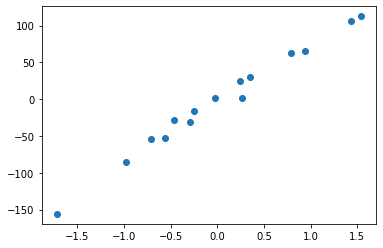

In [6]:
# wygeneruj zbiór na potrzeby modelowania regresji
X, y = make_regression(n_samples=15, n_features=1, noise=10)
# narysuj wygenerowany zbiór danych
plt.scatter(X,y)
plt.show()

### Eksport zbioru danych do pliku .csv

In [7]:
# Funkcja pomocnicza: zmiana nazwy kolumn w dataframe
# Uwaga: prefix musi być typu string
def rename_columns(df, prefix='x'):
    df = df.copy()
    df.columns = [prefix + str(i) for i in df.columns]
    return df

In [8]:
df = pd.DataFrame(X)
df = rename_columns(df)
df['y'] = y
df.head()

,x0,y
0,0.350531,30.621162
1,-0.027777,0.962401
2,-0.564343,-52.651148
3,-0.715256,-54.194975
4,-0.462830,-28.658176


Ćwiczenie: oblicz podstawowe statystyki zbioru df korzystając z funkcji *describe*

In [9]:
df.describe()

,x0,y
count,15.000000,15.000000
mean,0.035912,-1.203490
std,0.897659,72.268911
min,-1.720724,-155.943495
25%,-0.513586,-42.165053
50%,-0.027777,0.962401
75%,0.568822,46.609678
max,1.541195,112.720417


In [10]:
df.to_csv("dataset.csv", index = False)

## Analiza danych

In [11]:
# import przygotowanego zbioru danych
data = pd.read_csv('dataset.csv')

In [12]:
data

,x0,y
0,0.350531,30.621162
1,-0.027777,0.962401
2,-0.564343,-52.651148
3,-0.715256,-54.194975
4,-0.462830,-28.658176
5,-0.296530,-31.678958
6,0.265628,1.891391
7,0.940424,65.647502
8,0.787113,62.598193
9,1.431994,106.611702


ToDO: zaimportuj przykładowe dane z katalogu samples
Więcej danych dla regresji: http://people.sc.fsu.edu/~jburkardt/datasets/regression/regression.html

In [ ]:
#brains = pd.read_csv('samples/x01-prep.csv', delim_whitespace=True)
#brains

In [ ]:
data.sort_values(by = 'x0')

In [ ]:
#data['x0'] = brains['Brain_Weight']
#data['y'] = brains['Body_Weight']

In [ ]:
plt.scatter(data['x0'], data['y'])

# Modelowanie



Regresja liniowa:
\begin{align}
y = a*x + b
\end{align}

Pytanie: jak znaleźć najlepsze:


a = ? < nachylenie krzywej  
b = ? < punkt przecięcia z osią y (bias)   

Pytanie pomocnicze:

Co to znaczy: "najlepsze'?

## Pierwsze przybliżenie

\begin{align}
a = \frac{\sum_{i=1}^n(x_i - \overline{x}) * (y_i - \overline{y})}{\sum_{i=1}^n(x_i - \overline{x})^2}
\end{align}

\begin{align}
b = \overline{y} - a * \overline{x}
\end{align}

In [13]:
data

,x0,y
0,0.350531,30.621162
1,-0.027777,0.962401
2,-0.564343,-52.651148
3,-0.715256,-54.194975
4,-0.462830,-28.658176
5,-0.296530,-31.678958
6,0.265628,1.891391
7,0.940424,65.647502
8,0.787113,62.598193
9,1.431994,106.611702


In [14]:
data['x0'].mean()
data['y'].mean()
data['x - mean(x)'] = data['x0'] - data['x0'].mean()
data['y - mean(y)'] = data['y'] - data['y'].mean()
data['multiplied errors'] = data['x - mean(x)']*data['y - mean(y)']
data['x_errors_squared'] = data['x - mean(x)']**2

In [15]:
data

,x0,y,x - mean(x),y - mean(y),multiplied errors,x_errors_squared
0,0.350531,30.621162,0.314619,31.824653,10.012639,0.098985
1,-0.027777,0.962401,-0.063688,2.165891,-0.137942,0.004056
2,-0.564343,-52.651148,-0.600255,-51.447657,30.881696,0.360306
3,-0.715256,-54.194975,-0.751168,-52.991484,39.805493,0.564253
4,-0.462830,-28.658176,-0.498742,-27.454686,13.692792,0.248743
5,-0.296530,-31.678958,-0.332442,-30.475468,10.131334,0.110518
6,0.265628,1.891391,0.229716,3.094881,0.710944,0.052769
7,0.940424,65.647502,0.904512,66.850992,60.467520,0.818142
8,0.787113,62.598193,0.751201,63.801683,47.927914,0.564304
9,1.431994,106.611702,1.396082,107.815192,150.518855,1.949045


In [16]:
a1 = data['multiplied errors'].sum()
a2 = data['x_errors_squared'].sum()
a = a1/a2
print(a)

79.9392435048348


In [17]:
b = data['y'].mean() - a*data['x0'].mean()
b

-4.0742573330555185

In [18]:
data['predicted'] = a*data['x0'] + b

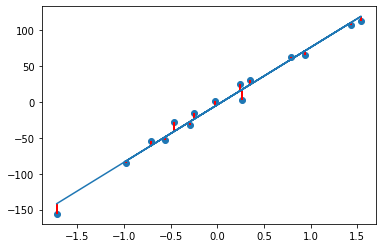

In [19]:
plt.plot(data['x0'], data['predicted'])
plt.scatter(data['x0'], data['y'])
for i in data['x0']:
    plt.vlines(data['x0'],data['predicted'], data['y'], colors = 'r' )

## Ewaluacja

Na ile dobry jest ten model?

Pierwsza miara: pierwiastek ze średniego błędu kwadratowego (Root Mean Square Error: RMSE):

\begin{equation}\label{eq:}
RMSE = \sqrt{\frac{\sum_{i=1}^n(p_i - y_i)^2}{n}}
\end{equation}

gdzie $p_i$ jest wartością prognozowaną (wygenerowaną przez model), zaś $y_i$ wartością rzeczywistą.


In [20]:
data['p - i'] = data['predicted'] - data['y']
data

,x0,y,x - mean(x),y - mean(y),multiplied errors,x_errors_squared,predicted,p - i
0,0.350531,30.621162,0.314619,31.824653,10.012639,0.098985,23.946911,-6.674252
1,-0.027777,0.962401,-0.063688,2.165891,-0.137942,0.004056,-6.294693,-7.257093
2,-0.564343,-52.651148,-0.600255,-51.447657,30.881696,0.360306,-49.187394,3.463753
3,-0.715256,-54.194975,-0.751168,-52.991484,39.805493,0.564253,-61.251270,-7.056296
4,-0.462830,-28.658176,-0.498742,-27.454686,13.692792,0.248743,-41.072513,-12.414337
5,-0.296530,-31.678958,-0.332442,-30.475468,10.131334,0.110518,-27.778674,3.900284
6,0.265628,1.891391,0.229716,3.094881,0.710944,0.052769,17.159834,15.268443
7,0.940424,65.647502,0.904512,66.850992,60.467520,0.818142,71.102510,5.455008
8,0.787113,62.598193,0.751201,63.801683,47.927914,0.564304,58.846982,-3.751211
9,1.431994,106.611702,1.396082,107.815192,150.518855,1.949045,110.398254,3.786552


In [21]:
import math
n = data.shape[0]
data['error2'] = data['p - i']**2
RMSE = math.sqrt(data['error2'].sum()/n)
print('RMSE = ', RMSE)

RMSE =  8.285907496592152


## Drugie przybliżenie: gradient descent

In [22]:
data

,x0,y,x - mean(x),y - mean(y),multiplied errors,x_errors_squared,predicted,p - i,error2
0,0.350531,30.621162,0.314619,31.824653,10.012639,0.098985,23.946911,-6.674252,44.545635
1,-0.027777,0.962401,-0.063688,2.165891,-0.137942,0.004056,-6.294693,-7.257093,52.665402
2,-0.564343,-52.651148,-0.600255,-51.447657,30.881696,0.360306,-49.187394,3.463753,11.997586
3,-0.715256,-54.194975,-0.751168,-52.991484,39.805493,0.564253,-61.251270,-7.056296,49.791307
4,-0.462830,-28.658176,-0.498742,-27.454686,13.692792,0.248743,-41.072513,-12.414337,154.115760
5,-0.296530,-31.678958,-0.332442,-30.475468,10.131334,0.110518,-27.778674,3.900284,15.212217
6,0.265628,1.891391,0.229716,3.094881,0.710944,0.052769,17.159834,15.268443,233.125346
7,0.940424,65.647502,0.904512,66.850992,60.467520,0.818142,71.102510,5.455008,29.757114
8,0.787113,62.598193,0.751201,63.801683,47.927914,0.564304,58.846982,-3.751211,14.071583
9,1.431994,106.611702,1.396082,107.815192,150.518855,1.949045,110.398254,3.786552,14.337976


In [23]:
a = 0 
b = 0

In [24]:
def pred(x):
    return a*x + b

In [25]:
def error(x, y):
    err = pred(x) - y
    return err

In [26]:
alpha = 0.01

In [27]:
err = error(data['x0'][0], data['y'][0])

In [28]:
b = b - alpha*err
b

0.306211623137639

In [29]:
a = a - alpha*err*data['x0'][0]
a

0.1073366091599796

iter =  1 RMSE =  256.60817997450306 a =  4.220836900959993 b =  -4.413977181009189


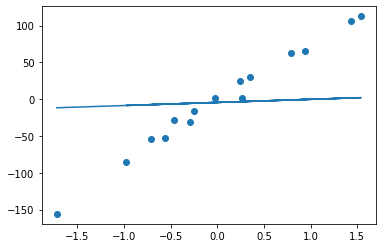

iter =  2 RMSE =  162.03000087723368 a =  12.440536500928005 b =  -3.961742212813852


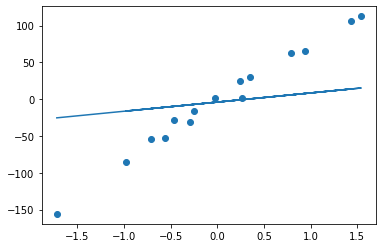

iter =  3 RMSE =  118.20519600492214 a =  19.76807998361636 b =  -3.618916457254697


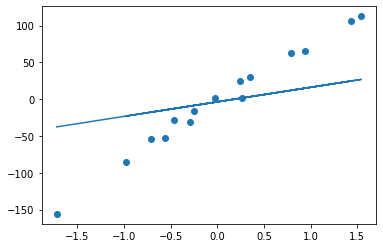

iter =  4 RMSE =  91.52728404288098 a =  26.3005453508295 b =  -3.365153380221455


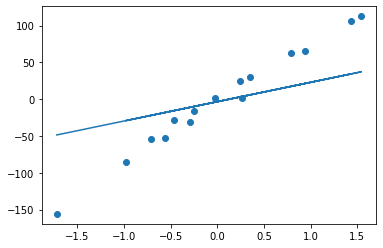

iter =  5 RMSE =  73.25509916495922 a =  32.12441306576119 b =  -3.183505847729557


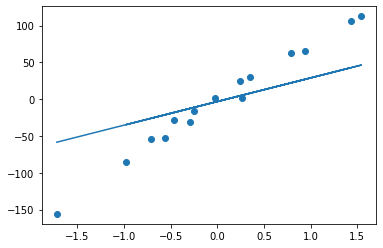

iter =  6 RMSE =  59.89983656168813 a =  37.31672771038165 b =  -3.059889564430744


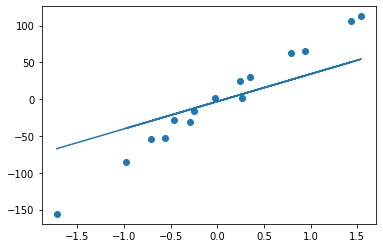

iter =  7 RMSE =  49.734918925127054 a =  41.94613164249251 b =  -2.982628349106551


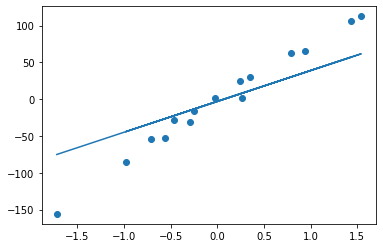

iter =  8 RMSE =  41.78497708547549 a =  46.07378484856245 b =  -2.9420690398924063


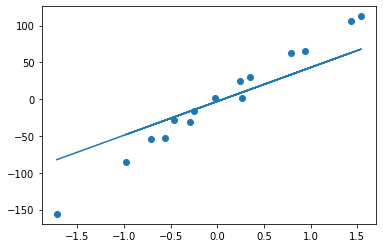

iter =  9 RMSE =  35.44717077514486 a =  49.75418360132163 b =  -2.9302556155336665


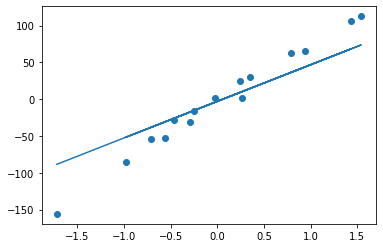

iter =  10 RMSE =  30.32392317215456 a =  53.035889123138574 b =  -2.940653651794639


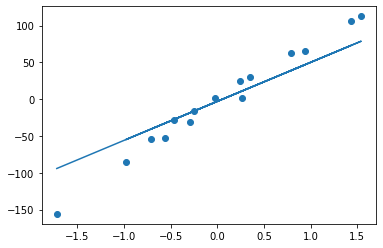

iter =  11 RMSE =  26.13989771111864 a =  55.9621762069647 b =  -2.9679175418433497


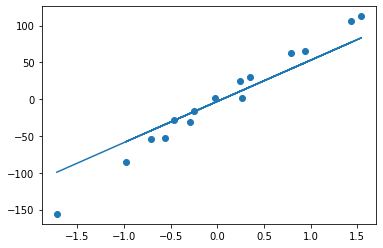

iter =  12 RMSE =  22.69701605979717 a =  58.57161063801286 b =  -3.007694028237549


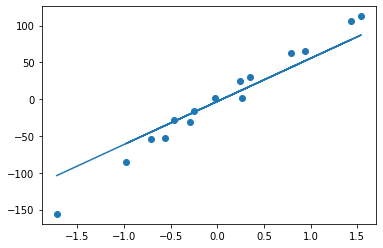

iter =  13 RMSE =  19.848357788184018 a =  60.89856327533266 b =  -3.056456549634535


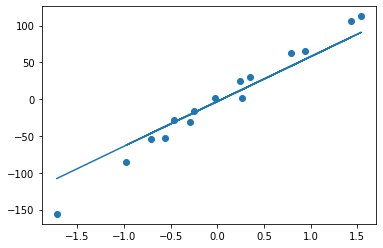

iter =  14 RMSE =  17.48215759212434 a =  62.973667778897145 b =  -3.1113657211680503


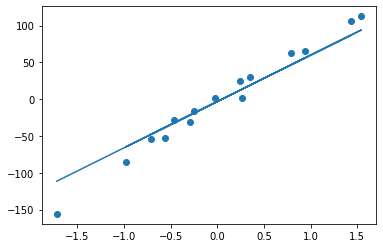

iter =  15 RMSE =  15.51154242086133 a =  64.82422819219198 b =  -3.1701519638112905


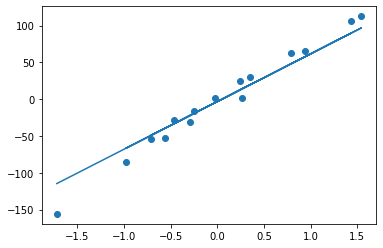

iter =  16 RMSE =  13.867705309608551 a =  66.47458190151056 b =  -3.2310168922968323


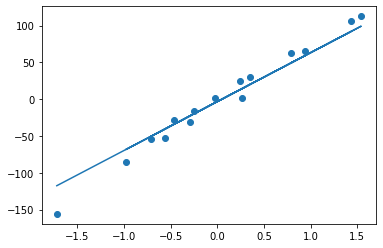

iter =  17 RMSE =  12.495233386479393 a =  67.9464228813838 b =  -3.292550578118098


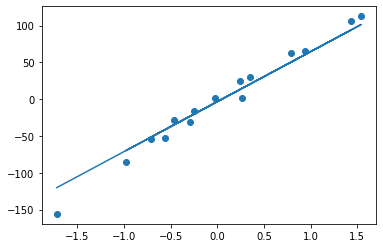

iter =  18 RMSE =  11.34884280602014 a =  69.25908959211992 b =  -3.353662236482455


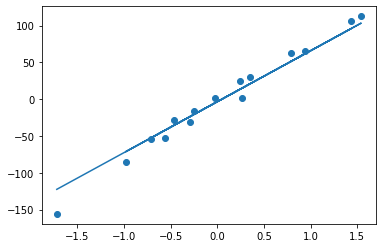

iter =  19 RMSE =  10.391065621657527 a =  70.42982141259108 b =  -3.413522254681852


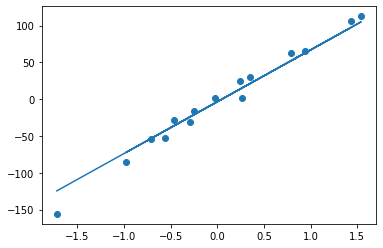

In [30]:
a = np.random.rand()
b = np.random.rand()

a = -5
b = -5
k = 20

#fig, ax = plt.subplots()   

for n in range(1, k):
    for i in range(0, data.shape[0]):
        err = error(data['x0'][i], data['y'][i])
        b = b - alpha*err
        a = a - alpha*err*data['x0'][i]
#        print('iter = ', n, a, b)

    RMSE = math.sqrt(((a*data['x0'] + b - data['y'])**2).sum()/n)
    print('iter = ', n, 'RMSE = ', RMSE, 'a = ', a, 'b = ', b)
    plt.plot(data['x0'], a*data['x0'] + b)
    plt.scatter(data['x0'], data['y'])
    plt.show()

## Wykres seaborn z regresją liniową

https://plot.ly/matplotlib/linear-fits/

In [31]:
data.head()

,x0,y,x - mean(x),y - mean(y),multiplied errors,x_errors_squared,predicted,p - i,error2
0,0.350531,30.621162,0.314619,31.824653,10.012639,0.098985,23.946911,-6.674252,44.545635
1,-0.027777,0.962401,-0.063688,2.165891,-0.137942,0.004056,-6.294693,-7.257093,52.665402
2,-0.564343,-52.651148,-0.600255,-51.447657,30.881696,0.360306,-49.187394,3.463753,11.997586
3,-0.715256,-54.194975,-0.751168,-52.991484,39.805493,0.564253,-61.251270,-7.056296,49.791307
4,-0.462830,-28.658176,-0.498742,-27.454686,13.692792,0.248743,-41.072513,-12.414337,154.115760


In [32]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(data['x0'],data['y'])

In [33]:
print(r_value)

0.992932794640512


In [34]:
print(slope, intercept)

79.9392435048348 -4.0742573330555185


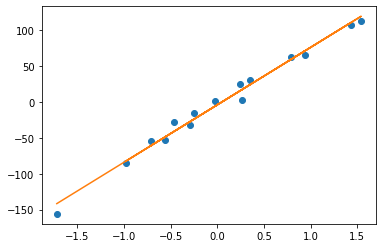

In [35]:
line = slope*data['x0']+intercept

plt.plot(data['x0'],data['y'],'o', data['x0'], line)

## Porównanie z arkuszem Google

ToDO: Sprawdź w arkuszu Google, w szczególności R^2

## Porównanie z Dataiku

ToDo: sprawdź w Dataiku